In [2]:
import cascade.roadway_manager
import numpy as np
#loading CASCADE simulations
data = np.load ('/CASCADE/scripts/FLOOD ANALYSIS/OCR_IL_Status_Quo_S0_Accretional_Sink.npz', allow_pickle=True)
data

NpzFile '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/OCR_IL_Status_Quo_S0_Accretional_Sink.npz' with keys: cascade

In [19]:
cascade_object = data['cascade'][0]
dir(cascade_object)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_alongshore_transport_module',
 '_b3d_break',
 '_background_erosion',
 '_barrier3d',
 '_beach_nourishment_module',
 '_brie_coupler',
 '_community_break',
 '_community_economics_module',
 '_dune_design_elevation',
 '_dune_file',
 '_dune_minimum_elevation',
 '_elevation_file',
 '_enable_shoreline_offset',
 '_filename',
 '_group_roadway_abandonment',
 '_initial_beach_width',
 '_nourish_now',
 '_nourishment_interval',
 '_nourishment_volume',
 '_nourishments',
 '_nt',
 '_num_cores',
 '_number_of_communities',
 '_ny',
 '_overwash_filter',
 '_overwash_to_dune',
 '_parameter_file',
 '_rebuild_dune_now',
 '_rmax',
 '_rmin',
 '_ro

In [41]:
# cascade_object.barrier3d[34].RSLR
# Get the RSLR time series from the first Barrier3D model (it's the same for all)
rslr_time_series = cascade_object.barrier3d[20].RSLR

# Calculate the cumulative sum to get total RSLR at each year
total_rslr = np.cumsum(rslr_time_series)

# Define the years you want to check
years_to_check = [24, 49, 74, 99]

print("--- Total Sea Level Rise (m) from Simulation ---")
for year in years_to_check:
    # Python uses 0-based indexing, so we subtract 1
    index = year - 1
    if index < len(total_rslr):
        print(f"Year {year}: {total_rslr[index]:.3f} m")




--- Total Sea Level Rise (m) from Simulation ---
Year 24: 0.017 m
Year 49: 0.036 m
Year 74: 0.057 m
Year 99: 0.077 m


In [6]:
import pandas as pd
Daily_WL_MHW = pd.read_csv('/CASCADE/scripts/FLOOD ANALYSIS/Daily_WL_MHW.csv')
Daily_WL_NAVD = pd.read_csv('/CASCADE/scripts/FLOOD ANALYSIS/Daily_WL_NAVD.csv')

In [7]:
Daily_WL_MHW['t'] = pd.to_datetime(Daily_WL_MHW['t'])
Daily_WL_NAVD['t'] = pd.to_datetime(Daily_WL_NAVD['t'])

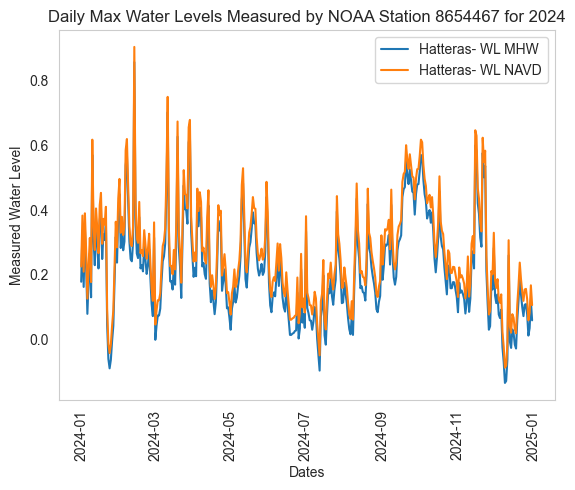

In [8]:
import matplotlib.pyplot as plt 
plt.plot(Daily_WL_MHW['t'], Daily_WL_MHW['v'], label= 'Hatteras- WL MHW')
plt.plot(Daily_WL_NAVD['t'], Daily_WL_NAVD['v'], label= 'Hatteras- WL NAVD')

plt.xlabel('Dates')  # Rotates the label vertically
plt.ylabel('Measured Water Level')
plt.title('Daily Max Water Levels Measured by NOAA Station 8654467 for 2024')
plt.grid()
plt.legend()
plt.xticks(rotation=90)
plt.show()

In [9]:
# yesrs of interest
target_years = [24, 49, 74, 99]
# Check if the roadways is not empty
if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    # Loop through each target year
    for year in target_years:
        print(f"\n Data for Year {year}: ")    
        # Loop through each domain (roadway segment)
        for i, road_segment in enumerate(cascade_object.roadways):
            
            # Access the time series for the current road segment
            elevation_time_series = road_segment._road_ele_TS
            elevation = elevation_time_series[year]
            print(f"Domain {i}: Road Elevation = {elevation}")


 Data for Year 24: 
Domain 0: Road Elevation = 0.0
Domain 1: Road Elevation = 0.0
Domain 2: Road Elevation = 0.0
Domain 3: Road Elevation = 0.0
Domain 4: Road Elevation = 0.0
Domain 5: Road Elevation = 0.0
Domain 6: Road Elevation = 0.0
Domain 7: Road Elevation = 0.0
Domain 8: Road Elevation = 0.0
Domain 9: Road Elevation = 0.0
Domain 10: Road Elevation = 0.0
Domain 11: Road Elevation = 0.0
Domain 12: Road Elevation = 0.0
Domain 13: Road Elevation = 0.0
Domain 14: Road Elevation = 0.0
Domain 15: Road Elevation = 1.2818078547070995
Domain 16: Road Elevation = 1.2818078547070995
Domain 17: Road Elevation = 1.2818078547070995
Domain 18: Road Elevation = 1.2818078547070995
Domain 19: Road Elevation = 1.2818078547070995
Domain 20: Road Elevation = 1.2818078547070995
Domain 21: Road Elevation = 1.2818078547070995
Domain 22: Road Elevation = 1.2818078547070995
Domain 23: Road Elevation = 1.2818078547070995
Domain 24: Road Elevation = 1.2818078547070995
Domain 25: Road Elevation = 1.281807854

In [10]:
#exporting road elevations for aech domain categorized by the years

results_list = []
target_years = [24, 49, 74, 99]

if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways):
            elevation_time_series = road_segment._road_ele_TS

            if year < len(elevation_time_series):
                elevation = elevation_time_series[year]

                result_row = {
                    'Year': year,
                    'Domain': i,
                    'Road_Elevation': elevation
                }
                results_list.append(result_row)

            else:
                print(f"Data for Year {year}, Domain {i} is not available.")

#convert the list to a DataFrame and save it
if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    results_df = pd.DataFrame(results_list)
    output_filename = 'road_elevations_by_year.csv'

    results_df.to_csv(output_filename, index=False)
    print(results_df.head()) 


   Year  Domain  Road_Elevation
0    24       0             0.0
1    24       1             0.0
2    24       2             0.0
3    24       3             0.0
4    24       4             0.0


In [11]:
#load the csv files for road elvation and water level
road_elevation = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/road_elevations_by_year.csv'
water_level_NAVD = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/Daily_WL_NAVD.csv'
road_df = pd.read_csv(road_elevation)
water_NAVD_df = pd.read_csv(water_level_NAVD)

In [12]:
#daily max water level (NAVD)
daily_tidal_levels_NAVD= water_NAVD_df['v'].values
daily_tidal_levels_NAVD

array([ 0.225,  0.382,  0.209,  0.389,  0.274,  0.126,  0.23 ,  0.313,
        0.177,  0.616,  0.355,  0.276,  0.404,  0.344,  0.266,  0.414,
        0.452,  0.295,  0.372,  0.354,  0.409,  0.093, -0.013, -0.042,
       -0.016,  0.042,  0.089,  0.228,  0.363,  0.284,  0.435,  0.495,
        0.329,  0.378,  0.322,  0.349,  0.584,  0.618,  0.475,  0.35 ,
        0.295,  0.288,  0.348,  0.902,  0.421,  0.312,  0.298,  0.424,
        0.266,  0.276,  0.257,  0.337,  0.291,  0.249,  0.276,  0.326,
        0.237,  0.157,  0.119,  0.361,  0.046,  0.09 ,  0.121,  0.121,
        0.142,  0.224,  0.288,  0.303,  0.343,  0.508,  0.748,  0.34 ,
        0.226,  0.227,  0.201,  0.276,  0.216,  0.365,  0.672,  0.331,
        0.271,  0.175,  0.343,  0.522,  0.449,  0.445,  0.404,  0.654,
        0.677,  0.379,  0.305,  0.24 ,  0.268,  0.242,  0.465,  0.396,
        0.454,  0.424,  0.272,  0.283,  0.248,  0.234,  0.379,  0.46 ,
        0.22 ,  0.162,  0.198,  0.167,  0.125,  0.162,  0.269,  0.414,
      

In [44]:
#subtractibg NAVD and constant 0.26 (MHW) 
daily_tidal_MHW = daily_tidal_levels_NAVD - 0.26
daily_tidal_MHW

array([-0.035,  0.122, -0.051,  0.129,  0.014, -0.134, -0.03 ,  0.053,
       -0.083,  0.356,  0.095,  0.016,  0.144,  0.084,  0.006,  0.154,
        0.192,  0.035,  0.112,  0.094,  0.149, -0.167, -0.273, -0.302,
       -0.276, -0.218, -0.171, -0.032,  0.103,  0.024,  0.175,  0.235,
        0.069,  0.118,  0.062,  0.089,  0.324,  0.358,  0.215,  0.09 ,
        0.035,  0.028,  0.088,  0.642,  0.161,  0.052,  0.038,  0.164,
        0.006,  0.016, -0.003,  0.077,  0.031, -0.011,  0.016,  0.066,
       -0.023, -0.103, -0.141,  0.101, -0.214, -0.17 , -0.139, -0.139,
       -0.118, -0.036,  0.028,  0.043,  0.083,  0.248,  0.488,  0.08 ,
       -0.034, -0.033, -0.059,  0.016, -0.044,  0.105,  0.412,  0.071,
        0.011, -0.085,  0.083,  0.262,  0.189,  0.185,  0.144,  0.394,
        0.417,  0.119,  0.045, -0.02 ,  0.008, -0.018,  0.205,  0.136,
        0.194,  0.164,  0.012,  0.023, -0.012, -0.026,  0.119,  0.2  ,
       -0.04 , -0.098, -0.062, -0.093, -0.135, -0.098,  0.009,  0.154,
      

--- Calculated Flooded Days ---
     Year  Domain  Flooded_Days
0      24       0           357
1      24       1           357
2      24       2           357
3      24       3           357
4      24       4           357
..    ...     ...           ...
271    99      64           357
272    99      65           357
273    99      66           357
274    99      67           357
275    99      68           357

[276 rows x 3 columns]

--- Pivoted Data for Heatmap ---
Year     24   49   74   99
Domain                    
0       357  357  357  357
1       357  357  357  357
2       357  357  357  357
3       357  357  357  357
4       357  357  357  357
...     ...  ...  ...  ...
64      357  357  357  357
65      357  357  357  357
66      357  357  357  357
67      357  357  357  357
68      357  357  357  357

[69 rows x 4 columns]

> Plot saved as 'heatmap_scenario_IL.png'


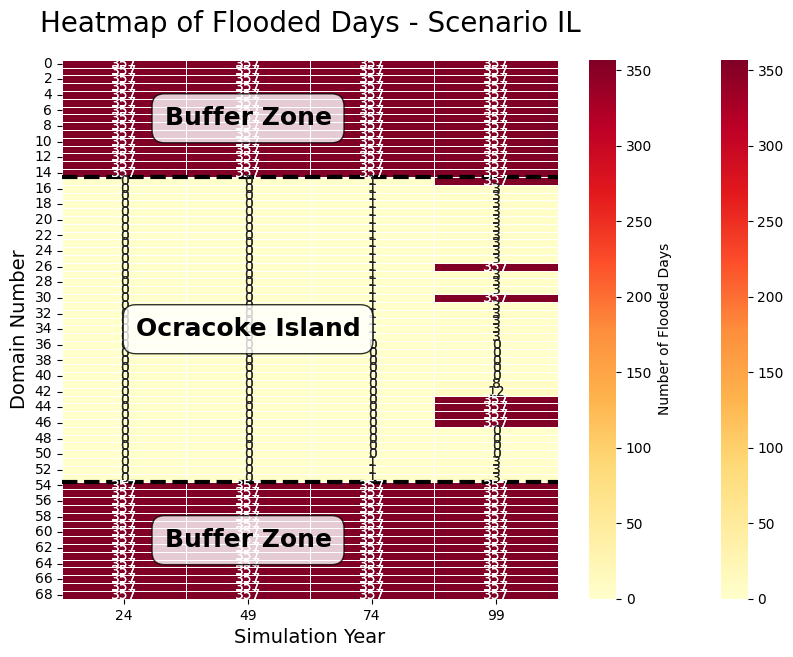

In [50]:
import seaborn as sns
flooded_days_results = []

for index, road_row in road_df.iterrows():
    # Get the specific data from the current row
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation']
    
    # Compare directly against the single array of 365 daily levels
    is_flooded = road_elevation < daily_tidal_levels_NAVD
    
    # Count how many days the road was flooded
    flooded_days_count = np.sum(is_flooded)
    
    # Append the result to our list
    flooded_days_results.append({
        'Year': year,
        'Domain': domain,
        'Flooded_Days': flooded_days_count
    })

# Convert the list of results into a new DataFrame
results_df = pd.DataFrame(flooded_days_results)

print("--- Calculated Flooded Days ---")
print(results_df)

# --- 3. Pivot the Data for Visualization ---
# This is the key step to prepare for the heatmap.
# We need a 2D grid: Domains as rows, Years as columns, and Flooded_Days as the values.
heatmap_data = results_df.pivot(index='Domain', columns='Year', values='Flooded_Days')

print("\n--- Pivoted Data for Heatmap ---")
print(heatmap_data)


# --- 4. Generate the Heatmap ---
plt.style.use('default')
plt.figure(figsize=(10, 7)) # Adjust figure size for better readability

# Use Seaborn's heatmap function
sns.heatmap(
    heatmap_data, 
    annot=True,     # Write the data value in each cell
    fmt="d",        # Format the numbers as integers (days)
    cmap="YlOrRd",  # A yellow-orange-red color map shows low-to-high severity well
    linewidths=.5,  # Add lines between cells
    linecolor='black'
)
ax = sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Number of Flooded Days'})

# Add horizontal lines to delineate regions
ax.axhline(y=15, color='black', linestyle='--', linewidth=3)
ax.axhline(y=54, color='black', linestyle='--', linewidth=3)

# Define properties for text labels and their bounding boxes
text_props = dict(ha='center', va='center', fontsize=18, color='black', weight='bold')
bbox_props = dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1, alpha=0.8)

# Place text labels in the middle of each delineated region
# Note: The x-coordinate (1.5) places the text between the 2nd and 3rd columns.
# Note: The y-coordinate is the position in terms of rows from the top.
plt.text(1.5, 7.5, 'Buffer Zone', **text_props, bbox=bbox_props)
plt.text(1.5, 34.5, 'Ocracoke Island', **text_props, bbox=bbox_props)
plt.text(1.5, 61.5, 'Buffer Zone', **text_props, bbox=bbox_props)

# Set titles and labels
plt.title(f'Heatmap of Flooded Days - Scenario IL', fontsize=20, pad=20)
plt.xlabel('Simulation Year', fontsize=14)
plt.ylabel('Domain Number', fontsize=14)
plt.yticks(rotation=0)

# Save the figure to a file
plot_output_filename = f'heatmap_scenario_IL.png'
plt.savefig(plot_output_filename, bbox_inches='tight', dpi=300)
print(f"\n> Plot saved as '{plot_output_filename}'")

# Display the final plot
plt.show()

